# CustIntel: AI-Powered Smart Customer Intelligence Platform

**Dataset:** [Olist Brazilian E-commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle) —
~100k real orders from a Brazilian multi-seller marketplace, 2016-2018.

Pipeline: Raw CSVs → SQLite star schema → EDA → Customer features (RFM) →
Classic ML (LTV + churn) → Deep learning (next-category MLP) → Sentiment →
AI Business Chatbot (ask anything) → Streamlit dashboard.

**Before running:** download the 9 CSVs from the Kaggle link above and place them in `data/raw/`:
`olist_customers_dataset.csv`, `olist_geolocation_dataset.csv`, `olist_order_items_dataset.csv`,
`olist_order_payments_dataset.csv`, `olist_order_reviews_dataset.csv`, `olist_orders_dataset.csv`,
`olist_products_dataset.csv`, `olist_sellers_dataset.csv`, `product_category_name_translation.csv`.

In [6]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "src").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/ modules use plain imports (`from config import ...`, `from database import ...`),
# so src/ must come FIRST on the path -- otherwise a folder that happens to be
# named "database" elsewhere in the project can shadow src/database.py.
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR in sys.path:
    sys.path.remove(SRC_DIR)
sys.path.insert(0, SRC_DIR)

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("src folder exists :", (PROJECT_ROOT / "src").is_dir())

Current directory : C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\FINAL_Project\CustIntel_2\notebooks
Project root      : C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\FINAL_Project\CustIntel_2
src folder exists : True


In [7]:
from config import RAW_DIR, OLIST_FILES

missing = [name for name in OLIST_FILES.values() if not (RAW_DIR / name).exists()]
if missing:
    print("Missing raw files in", RAW_DIR, ":")
    for name in missing:
        print("  -", name)
    print("\nDownload them from https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")
else:
    print("All 9 raw Olist files found in", RAW_DIR)

All 9 raw Olist files found in C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\FINAL_Project\CustIntel_2\data\raw


## 1. Build the SQLite database (star schema)

In [8]:
from ingest import load_all

quality_report = load_all()
print("Database built. Data-quality report:")
for key, value in quality_report.items():
    print(f"  {key}: {value}")

Database built. Data-quality report:
  products_missing_category: 610
  review_id_duplicates: 814
  orders_with_multiple_reviews: 551
  order_items_orphaned: 0
  orders_without_items: 775
  orders_total: 99441
  orders_delivered: 96478
  customers_total: 99441
  unique_people: 96096
  date_range: ['2016-09-04 21:15:19', '2018-10-17 17:30:18']


Notes on the data-quality report:
- **products_missing_category (610):** a handful of products have a blank category; filled in as `"unknown"`.
- **review_id_duplicates (814) / orders_with_multiple_reviews (551):** a few orders were reviewed twice; the
  most recent review is kept.
- **orders_without_items (775):** a small number of orders (mostly `canceled`/`unavailable`) have no line items.

## 2. Look at the raw data

In [9]:
import pandas as pd
from database import query_dataframe

orders = query_dataframe("SELECT * FROM fact_orders LIMIT 5")
display(orders)

customers = query_dataframe("SELECT * FROM dim_customers LIMIT 5")
display(customers)

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,price,freight_value,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,5.0


,customer_id,customer_unique_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


## 3. A SQL question: revenue by category

In [10]:
sales_by_category = query_dataframe('''
    SELECT
        p.product_category,
        ROUND(SUM(o.price), 2) AS revenue,
        COUNT(*) AS items_sold
    FROM fact_order_items o
    JOIN dim_products p ON o.product_id = p.product_id
    WHERE o.order_status = 'delivered'
    GROUP BY p.product_category
    ORDER BY revenue DESC
''')
display(sales_by_category.head(15))

,product_category,revenue,items_sold
0,health_beauty,1233131.72,9465
1,watches_gifts,1166176.98,5859
2,bed_bath_table,1023434.76,10953
3,sports_leisure,954852.55,8431
4,computers_accessories,888724.61,7644
5,furniture_decor,711927.69,8160
6,housewares,615628.69,6795
7,cool_stuff,610204.10,3718
8,auto,578966.65,4140
9,toys,471286.48,4030


## 4. Charts (EDA)

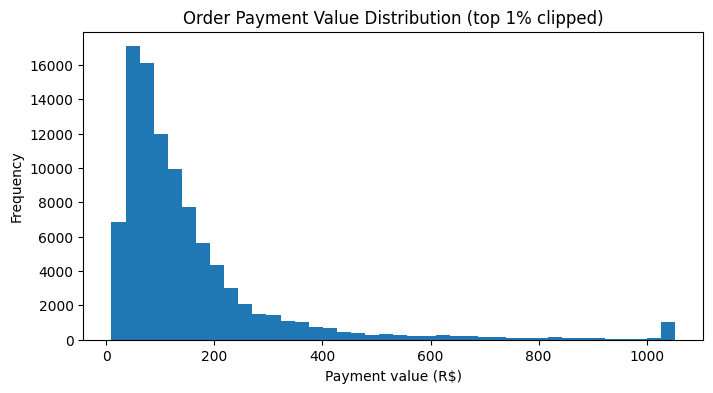

In [11]:
import matplotlib.pyplot as plt

orders_full = query_dataframe("SELECT payment_value FROM fact_orders WHERE order_status='delivered'")

plt.figure(figsize=(8, 4))
orders_full["payment_value"].clip(upper=orders_full["payment_value"].quantile(0.99)).plot(kind="hist", bins=40)
plt.title("Order Payment Value Distribution (top 1% clipped)")
plt.xlabel("Payment value (R$)")
plt.show()

<Figure size 900x400 with 0 Axes>

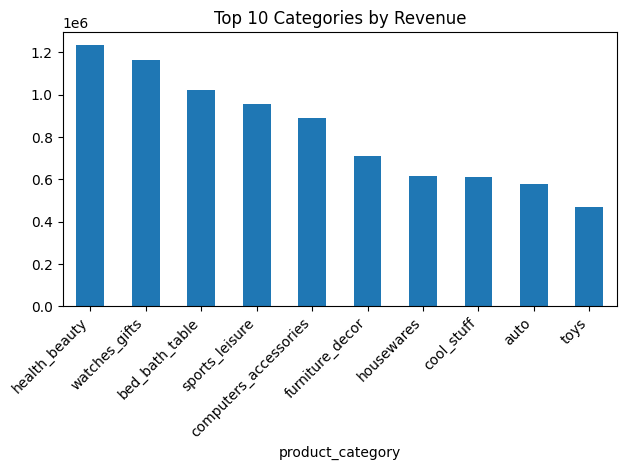

In [12]:
plt.figure(figsize=(9, 4))
sales_by_category.head(10).plot(x="product_category", y="revenue", kind="bar", legend=False)
plt.title("Top 10 Categories by Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Feature engineering

Builds one row per customer with RFM-style features and two targets:
`future_spend_180d` (LTV target) and `will_churn` (1 = did not buy again within 180 days).
Features are computed strictly *before* a cutoff date, and the targets strictly *after* it, to avoid leakage.

In [13]:
from features import build_customer_features

features_df = build_customer_features()
display(features_df.head())
print("Rows:", len(features_df))
print("Churn rate:", round(features_df["will_churn"].mean(), 3))

,customer_id,order_count,total_spend,avg_order_value,avg_review_score,days_since_last_purchase,customer_tenure_days,future_spend_180d,will_churn
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,356,356,0.0,1
1,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,140,140,0.0,1
2,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,107,107,0.0,1
3,00053a61a98854899e70ed204dd4bafe,1,419.18,419.18,1.0,2,2,0.0,1
4,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,4.0,362,362,0.0,1


Rows: 55907
Churn rate: 0.988


**Note:** Olist has a very low repeat-purchase rate — the great majority of customers buy exactly once.
That is why the churn rate above is close to 1.0; it is a real property of this dataset, not a bug.

## 6. Train the classic ML models (LTV regression + churn classification)

In [14]:
from train_ml import train_models

ml_metrics = train_models()
ml_metrics

{'ltv': {'random_forest_r2': -0.0775,
  'random_forest_rmse': 21.74,
  'random_forest_mae': 3.62,
  'n_train': 44725,
  'n_test': 11182},
 'churn': {'random_forest_f1': 0.9085,
  'random_forest_f1_active_customers': 0.0271,
  'churn_rate': 0.9883,
  'n_train': 44725,
  'n_test': 11182,
  'note': "This dataset has a very low repeat-purchase rate (Olist is mostly one-time buyers), so churn is heavily imbalanced. The model is trained with class_weight='balanced'; judge it on the 'active customers' F1, not on accuracy."}}

Because of the one-time-buyer pattern noted above, both models are genuinely hard on this dataset:
LTV has almost no signal to predict future spend from a single past order, and churn is judged on the
**F1 for the minority "still active" class**, not accuracy, since always predicting "will churn" would
otherwise look artificially good.

## 7. Deep learning: next-purchase-category model (MLP)

In [15]:
from train_dl import train

dl_history = train()
dl_history

{'model_type': 'MLPClassifier (scikit-learn), hidden layers (128, 64)',
 'epochs_ran': 38,
 'n_categories': 74,
 'n_sequences': 16839,
 'n_train': 13471,
 'n_test': 3368,
 'test_accuracy': 0.8429,
 'test_top3_accuracy': 0.8881,
 'test_macro_f1': 0.7436,
 'note': 'Repeat purchases are rare on Olist, so this model is trained on a small number of sequences; treat the numbers as illustrative, not production-grade.'}

This is a genuine multi-layer perceptron neural network (`scikit-learn`'s `MLPClassifier`, hidden layers
128→64), trained on customers who bought from more than one category, to predict the category of their
next purchase from their last few categories. It is trained on scikit-learn instead of PyTorch to avoid a
multi-gigabyte GPU toolkit download for a model this small — the modelling idea (feed-forward neural
network on encoded sequences) is the same either way.

## 8. Sentiment analysis (Portuguese reviews)

In [16]:
from sentiment import analyze_reviews

reviews = query_dataframe('''
    SELECT review_score, review_comment_message
    FROM dim_reviews
    WHERE review_comment_message IS NOT NULL
''')
analyzed_reviews = analyze_reviews(reviews)
display(analyzed_reviews[["review_score", "review_comment_message", "sentiment", "themes"]].head(20))

,review_score,review_comment_message,sentiment,themes
0,1,nao recebi o produto e nem resposta da empresa,negative,[customer_service]
1,1,"PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA",negative,[delivery]
2,5,O pedido foi entregue antes do prazo pr0metido,positive,[delivery]
3,4,Só chegou uma parte do pedido ate agora..,positive,[delivery]
4,5,Tudo dentro do combinado,positive,[]
5,5,Chego dentro do prazo tudo bem embalado,positive,[delivery]
6,4,"Entrega rápida, bem embalado,produto muito bom...",positive,[delivery]
7,5,O produto chegou em perfeito estado e antes do...,positive,[delivery]
8,4,"Sei que esse não e o canal ideal, estou ha dia...",positive,[]
9,5,O produto chegou beeeeemmmm antes do prazo com...,positive,[delivery]


Reviews are in Brazilian Portuguese with no labelled sentiment, so `sentiment` comes from the star
rating the customer already gave (1-2→negative, 3→neutral, 4-5→positive), and `themes` comes
from Portuguese keyword matching (delivery, product quality, customer service, price, store experience).

In [17]:
print(analyzed_reviews["sentiment"].value_counts())
all_themes = [t for row in analyzed_reviews["themes"] for t in row]
pd.Series(all_themes).value_counts()

sentiment
positive    26398
negative    10839
neutral      3538
Name: count, dtype: int64


delivery            18229
store_experience     7443
product_quality      4480
customer_service     2274
price_value          1417
Name: count, dtype: int64

## 9. AI-powered business chatbot (ask anything)

The chatbot is an **AI agent**, not a fixed set of pattern-matched questions. It is given the live
database schema and the precomputed model reports, and it can query the database itself (read-only
`SELECT` statements) to work out the answer -- so it can answer *any* business question in plain English:
revenue, categories, churn, LTV, reviews, specific customers, model performance, trends, comparisons.
It also remembers the conversation, so follow-ups work.

**Setup (full AI agent):**
```bash
pip install google-genai
export GOOGLE_API_KEY="your-google-api-key"     # Windows PowerShell: $env:GOOGLE_API_KEY="your-google-api-key"
```
`GEMINI_API_KEY` also works, and a `.env` file with `GOOGLE_API_KEY=...` in the project root works too
(the chatbot calls `load_dotenv()`). Without a key, `answer_question` falls back to a limited offline
mode (churn / reviews / sales / LTV basics only) instead of failing.

In [18]:
import os

if os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY"):
    print("API key found -> full ask-anything AI agent is enabled.")
else:
    print("No GOOGLE_API_KEY set -> limited offline mode (churn / reviews / sales / LTV basics only).")

No GOOGLE_API_KEY set -> limited offline mode (churn / reviews / sales / LTV basics only).


In [19]:
from chatbot import answer_question

history = []

def ask(question):
    """Ask the business chatbot one question and keep the conversation memory."""
    print("\nQUESTION:", question)
    answer = answer_question(question, history=history)
    print("ANSWER:", answer)
    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": answer})
    return answer

questions = [
    "What categories have the highest sales?",
    "What is the average review score?",
    "What is customer LTV?",
    "Why is churn high?",
    "Which 5 customers have spent the most, and what's their churn risk?",
    "How does average order value differ between 5-star and 1-star reviewers?",
    "Is revenue concentrated in a few product categories or spread evenly?",
    "How is monthly revenue trending over time?",
    "How well are the LTV and churn models performing?",
    "And which of those categories has the lowest average review score?",
]

for question in questions:
    ask(question)


QUESTION: What categories have the highest sales?
ANSWER: (Offline mode) Top 5 categories by revenue:
     product_category    revenue
        health_beauty 1233131.72
        watches_gifts 1166176.98
       bed_bath_table 1023434.76
       sports_leisure  954852.55
computers_accessories  888724.61

QUESTION: What is the average review score?
ANSWER: (Offline mode) Average review score: 4.09 / 5.

QUESTION: What is customer LTV?
ANSWER: (Offline mode) LTV model report:
{
  "ltv": {
    "random_forest_r2": -0.0775,
    "random_forest_rmse": 21.74,
    "random_forest_mae": 3.62,
    "n_train": 44725,
    "n_test": 11182
  },
  "churn": {
    "random_forest_f1": 0.9085,
    "random_forest_f1_active_customers": 0.0271,
    "churn_rate": 0.9883,
    "n_train": 44725,
    "n_test": 11182,
    "note": "This dataset has a very low repeat-purchase rate (Olist is mostly one-time buyers), so churn is heavily imbalanced. The model is trained with class_weight='balanced'; judge it on the 'active c

### Ask your own question

Type any business question below and re-run the cell. Earlier questions are remembered, so you can ask follow-ups.

In [20]:
ask("Which product category has the most unhappy customers, and why might that be?")


QUESTION: Which product category has the most unhappy customers, and why might that be?
ANSWER: (Offline mode) Top 5 categories by revenue:
     product_category    revenue
        health_beauty 1233131.72
        watches_gifts 1166176.98
       bed_bath_table 1023434.76
       sports_leisure  954852.55
computers_accessories  888724.61


'(Offline mode) Top 5 categories by revenue:\n     product_category    revenue\n        health_beauty 1233131.72\n        watches_gifts 1166176.98\n       bed_bath_table 1023434.76\n       sports_leisure  954852.55\ncomputers_accessories  888724.61'

## 10. Run the Streamlit dashboard

From a terminal at the project root:

```bash
streamlit run app/streamlit_app.py
```

The dashboard has five pages:
- **Executive Dashboard** -- orders, revenue, customers, average review, model metrics and revenue by category
- **Customer Intelligence** -- per-customer LTV prediction, churn probability and the top churn-risk customers
- **Next Category AI** -- MLP next-category purchase prediction
- **Voice of Customer** -- review sentiment and top themes
- **Business Chatbot** -- the ask-anything AI agent from section 9, with conversation memory and a *Clear conversation* button

To enable the full chatbot in the dashboard, set `GOOGLE_API_KEY` in the same terminal before running
`streamlit run`. Without it the page shows a warning and runs in the limited offline mode.

> If the database is missing, the app tells you to run the pipeline first: `python src/ingest.py`,
> `python src/features.py`, `python src/train_ml.py`, `python src/train_dl.py`.